**Imports**

In [ ]:
!pip install category_encoders
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import chi2_contingency, uniform, randint
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer
from category_encoders import WOEEncoder
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    classification_report,
    precision_recall_curve,
    make_scorer
)


### Uploading the data

In [ ]:
df = pd.read_csv('/content/Telco_customer_churn.csv')
df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.8 MB/s eta 0:00:00


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


**Preprocessing**

In [ ]:
for c in df.columns:
  print(f'{c}: {df[c].nunique()}')

CustomerID: 7043
Count: 1
Country: 1
State: 1
City: 1129
Zip Code: 1652
Lat Long: 1652
Latitude: 1652
Longitude: 1651
Gender: 2
Senior Citizen: 2
Partner: 2
Dependents: 2
Tenure Months: 73
Phone Service: 2
Multiple Lines: 3
Internet Service: 3
Online Security: 3
Online Backup: 3
Device Protection: 3
Tech Support: 3
Streaming TV: 3
Streaming Movies: 3
Contract: 3
Paperless Billing: 2
Payment Method: 4
Monthly Charges: 1585
Total Charges: 6531
Churn Label: 2
Churn Value: 2
Churn Score: 85
CLTV: 3438
Churn Reason: 20


 Dropping leakage columns (such as churn label, churn score,...),
 as well as columns with either 1 value or with a distinct value for all rows (customerID, Count, Country,...)

In [ ]:
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long',
             'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
df['Total Charges'] = df['Monthly Charges'] * df['Tenure Months']

In [ ]:
df.describe()

,Tenure Months,Monthly Charges,Total Charges,Churn Value
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.581350,0.265370
std,24.559481,30.090047,2264.729447,0.441561
min,0.000000,18.250000,0.000000,0.000000
25%,9.000000,35.500000,394.000000,0.000000
50%,29.000000,70.350000,1393.600000,0.000000
75%,55.000000,89.850000,3786.100000,1.000000
max,72.000000,118.750000,8550.000000,1.000000


Identifying the numerical and categorical columns

In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns[:-1]
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

Numeric columns: ['Tenure Months', 'Monthly Charges', 'Total Charges']
Categorical columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


**Histograms of Numeric Features**

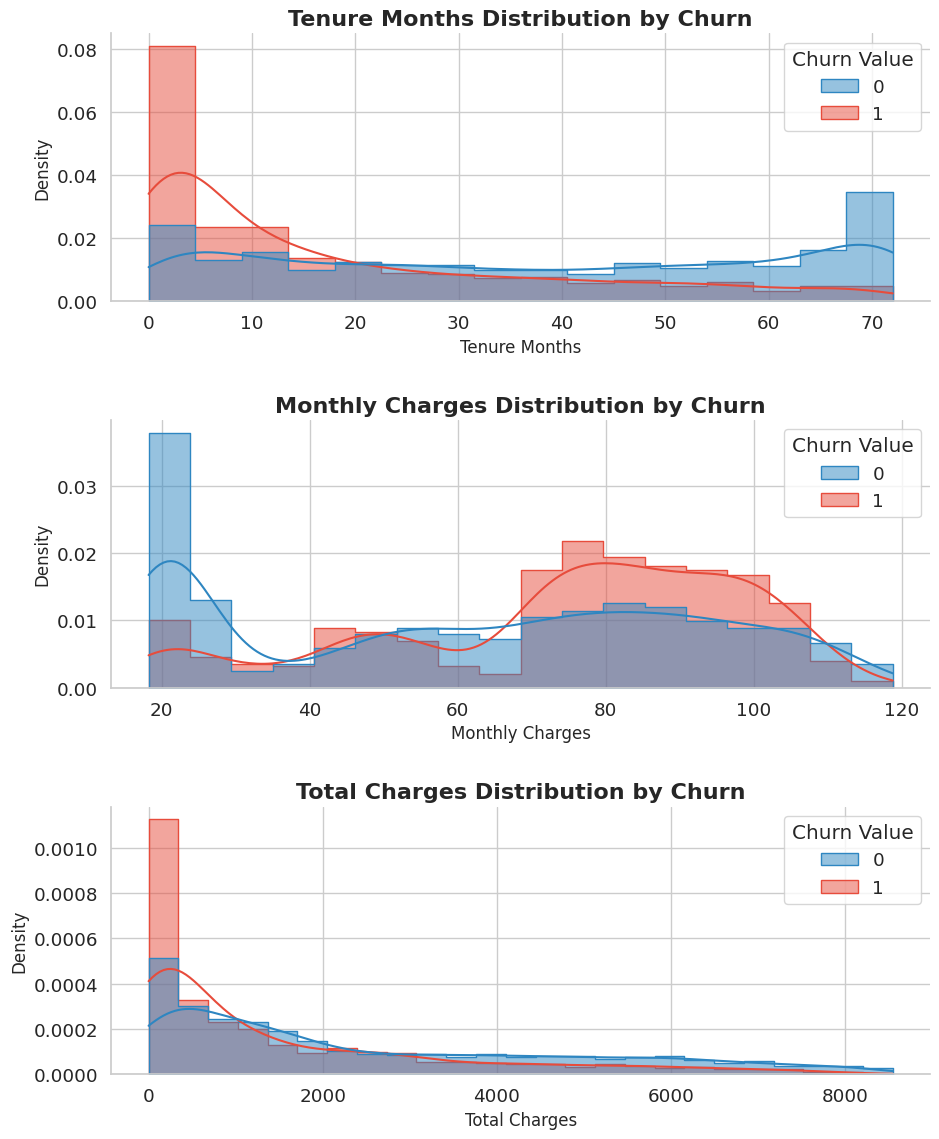

In [ ]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
numeric_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

custom_palette = {0: "#2E86C1", 1: "#E74C3C"}

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    sns.histplot(
        data=df,
        x=col,
        hue='Churn Value',
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        palette=custom_palette,
        alpha=0.5,
        ax=ax
    )

    ax.set_title(f'{col} Distribution by Churn', fontsize=16, weight='bold')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    sns.despine(ax=ax)

plt.tight_layout(pad=2.0)
plt.show()

**Box Plots for Tenure Months, Monthly Charges & Total Charges (Outliers detection)**

/tmp/ipython-input-297549959.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Stayed (0)', 'Churned (1)'])
/tmp/ipython-input-297549959.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Stayed (0)', 'Churned (1)'])
/tmp/ipython-input-297549959.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Stayed (0)', 'Churned (1)'])


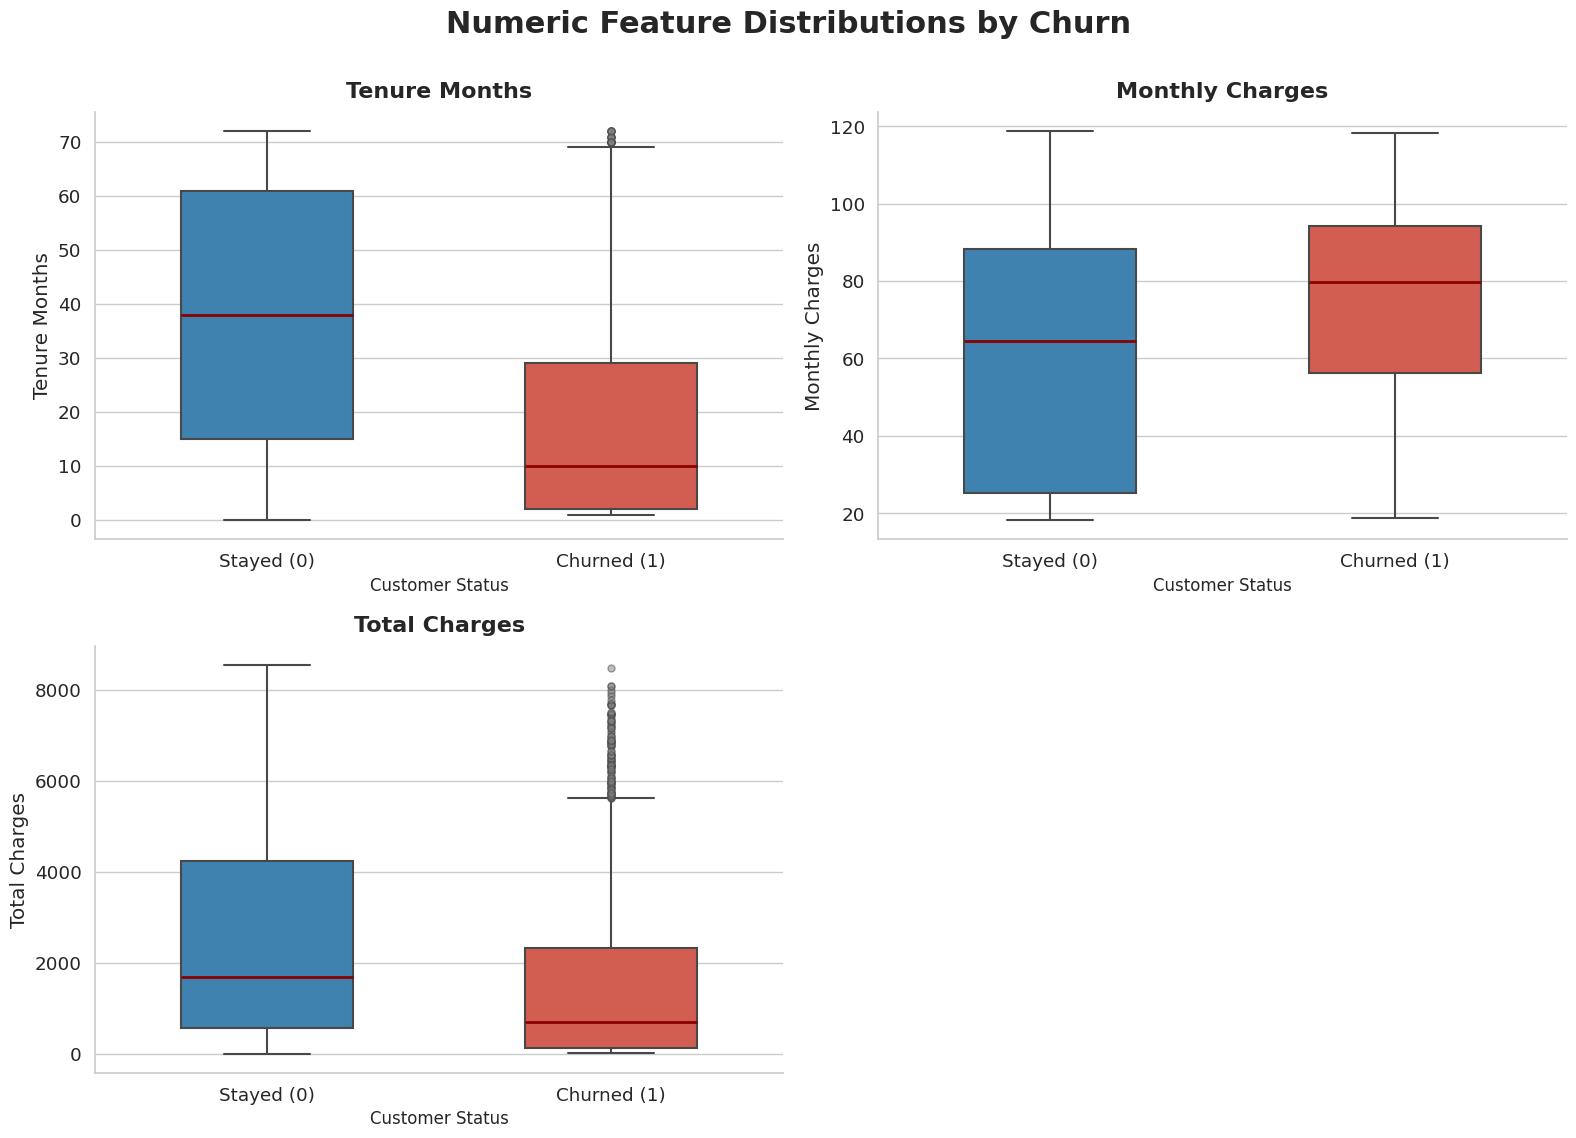

In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

features = ['Tenure Months', 'Monthly Charges', 'Total Charges']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

custom_palette = {0: "#2E86C1", 1: "#E74C3C"}
median_props = dict(color="darkred", linewidth=2)
flier_props = dict(marker="o", markerfacecolor="gray", markersize=5, alpha=0.5)

for i, col in enumerate(features):
    sns.boxplot(
        data=df,
        x='Churn Value',
        y=col,
        hue='Churn Value',
        legend=False,
        palette=custom_palette,
        width=0.5,
        linewidth=1.5,
        medianprops=median_props,
        flierprops=flier_props,
        ax=axes[i]
    )

    axes[i].set_title(f'{col}', fontsize=16, weight='bold', pad=10)
    axes[i].set_xlabel('Customer Status', fontsize=12)
    axes[i].set_xticklabels(['Stayed (0)', 'Churned (1)'])
    sns.despine(ax=axes[i])

axes[3].set_visible(False)

plt.suptitle("Numeric Feature Distributions by Churn", fontsize=22, weight='bold', y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Featue Engineering, add bins columns**

In [ ]:
labels = ["1-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
df['tenure_group'] = pd.cut(df['Tenure Months'], bins=range(0, 73, 12), labels=labels)



categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

In [ ]:
conditions_charges = [
    df["Monthly Charges"] <= 20,
    (df["Monthly Charges"] > 20) & (df["Monthly Charges"] <= 50),
    (df["Monthly Charges"] > 50) & (df["Monthly Charges"] <= 90),
    df["Monthly Charges"] > 90
]
choices_charges = ["0–20", "20–50", "50-90", "90-120"]
df["Monthly Charges range"] = np.select(conditions_charges, choices_charges, default="Undefined")


categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

**Bar Plots for Categorical Features**

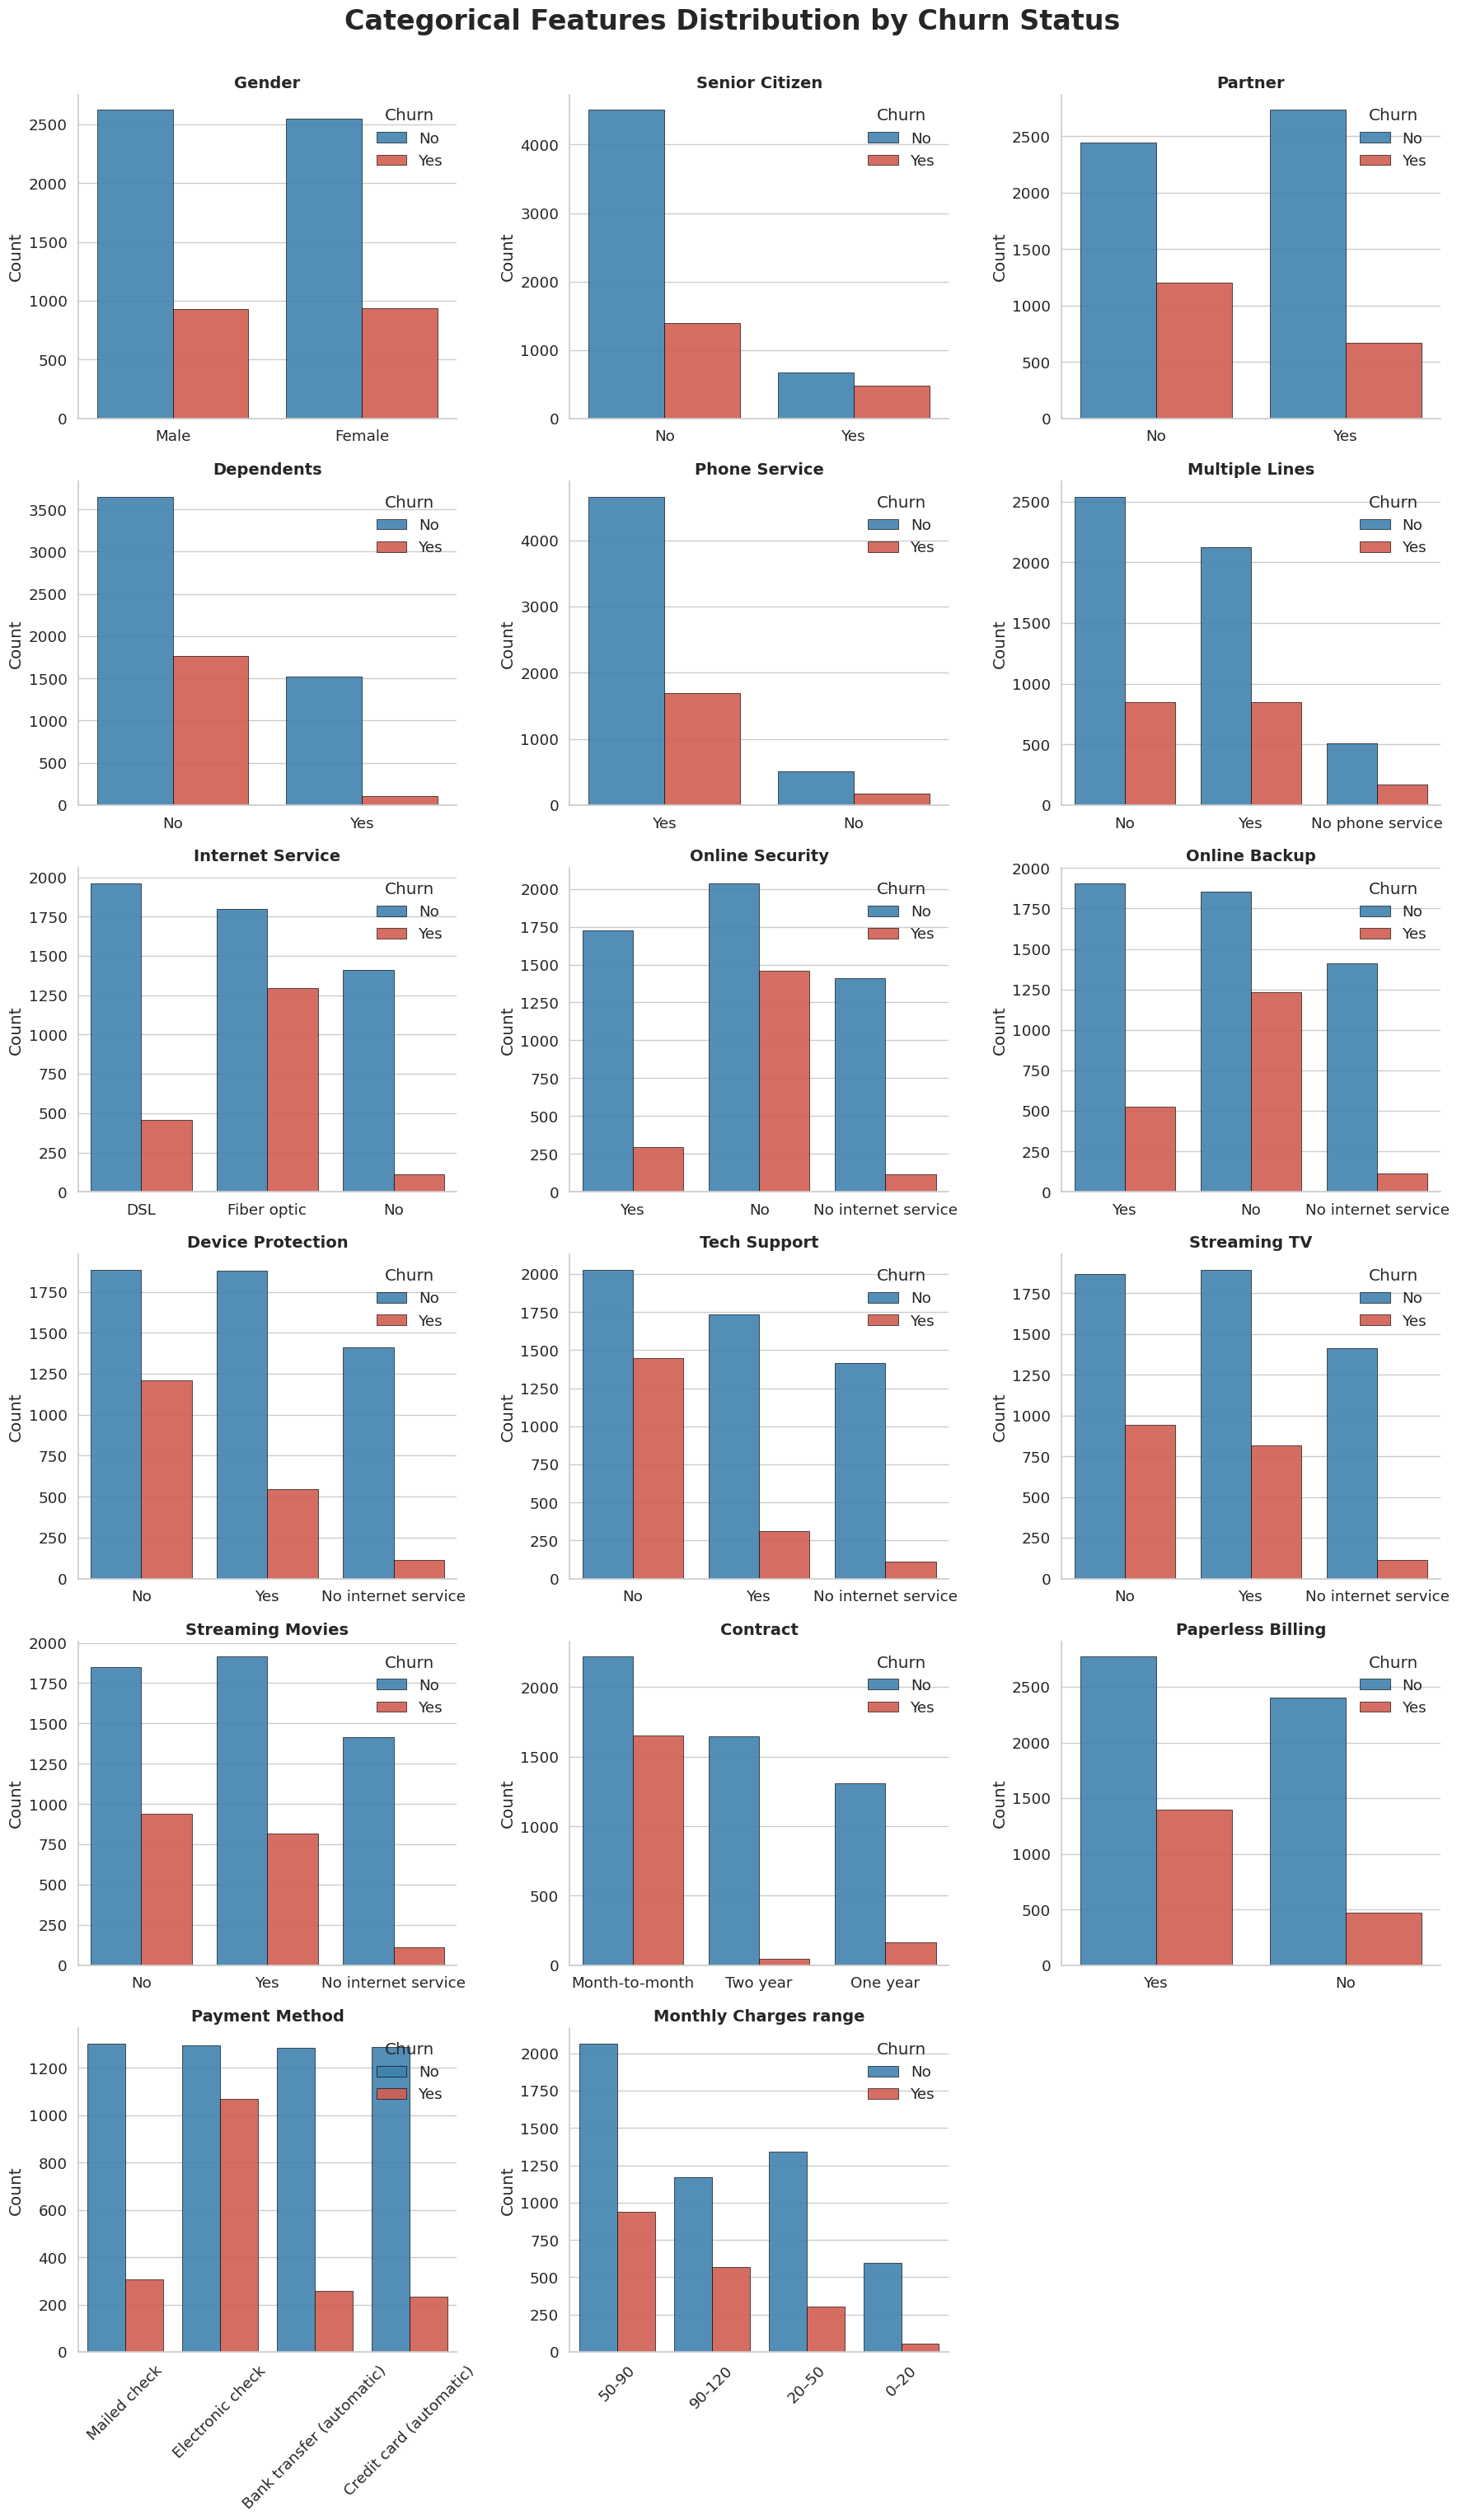

In [ ]:
exclude_cols = ['CustomerID', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason', 'Count', 'Country', 'State']
cat_cols = [c for c in df.columns if (df[c].dtype == 'object' or c == 'SeniorCitizen') and c not in exclude_cols]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

custom_palette = {0: "#2E86C1", 1: "#E74C3C"}

for i, col in enumerate(cat_cols):
    ax = axes[i]

    sns.countplot(
        data=df,
        x=col,
        hue='Churn Value',
        palette=custom_palette,
        alpha=0.9,
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )


    ax.set_title(f'{col}', fontsize=14, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(title='Churn', labels=['No', 'Yes'], loc='upper right', frameon=False)

    if df[col].nunique() > 3:
        ax.tick_params(axis='x', rotation=45)

    sns.despine(ax=ax)

for i in range(len(cat_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle("Categorical Features Distribution by Churn Status", fontsize=24, y=1.02, weight='bold')
plt.show()

**Churn Distribution**

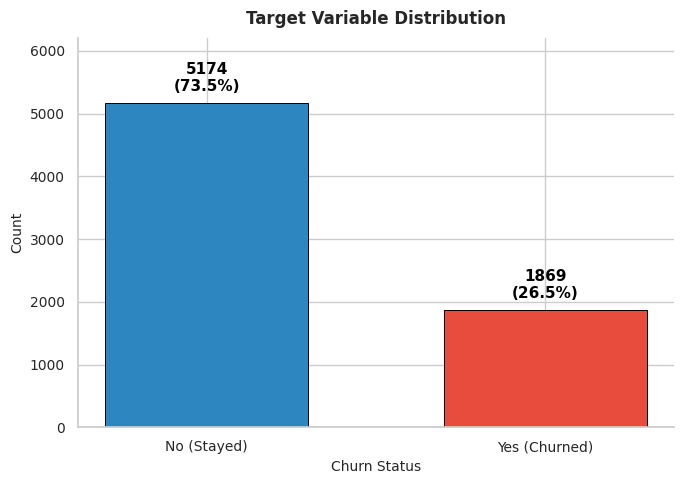

In [ ]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.0)

label_counts = df['Churn Value'].value_counts().sort_index()
total = label_counts.sum()
label_perc = 100 * label_counts / total

colors = ['#2E86C1', '#E74C3C']

plt.figure(figsize=(7, 5))
bars = plt.bar(label_counts.index, label_counts.values, color=colors, width=0.6, edgecolor='black', linewidth=0.7)

y_offset = total * 0.02

for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = label_perc.iloc[i]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + y_offset,
        f"{int(height)}\n({percentage:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black'
    )

plt.ylim(0, label_counts.max() * 1.2)

plt.xticks([0, 1], ['No (Stayed)', 'Yes (Churned)'], fontsize=10)
plt.yticks(fontsize=10)
plt.title('Target Variable Distribution', fontsize=12, weight='bold', pad=10)
plt.ylabel('Count', fontsize=10)
plt.xlabel('Churn Status', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

**Correlation between Numeric Features**

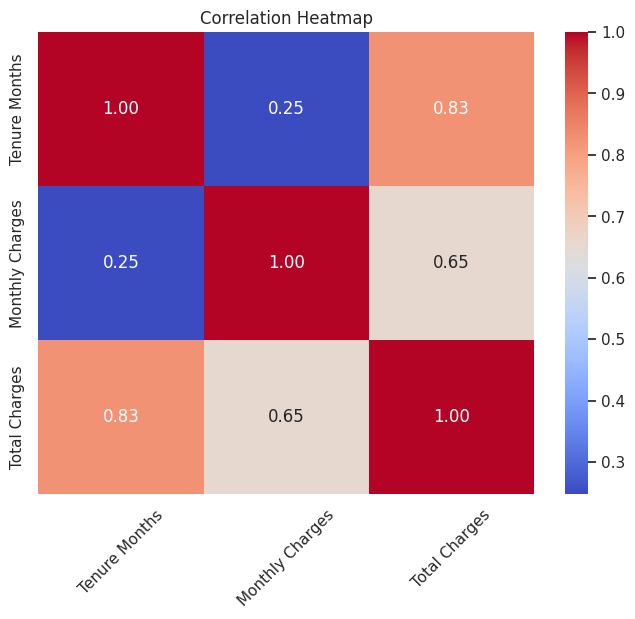

In [ ]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.show()

**Correlation between Categorical Features**

In [ ]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


cat_cols = categorical_cols
corr_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])



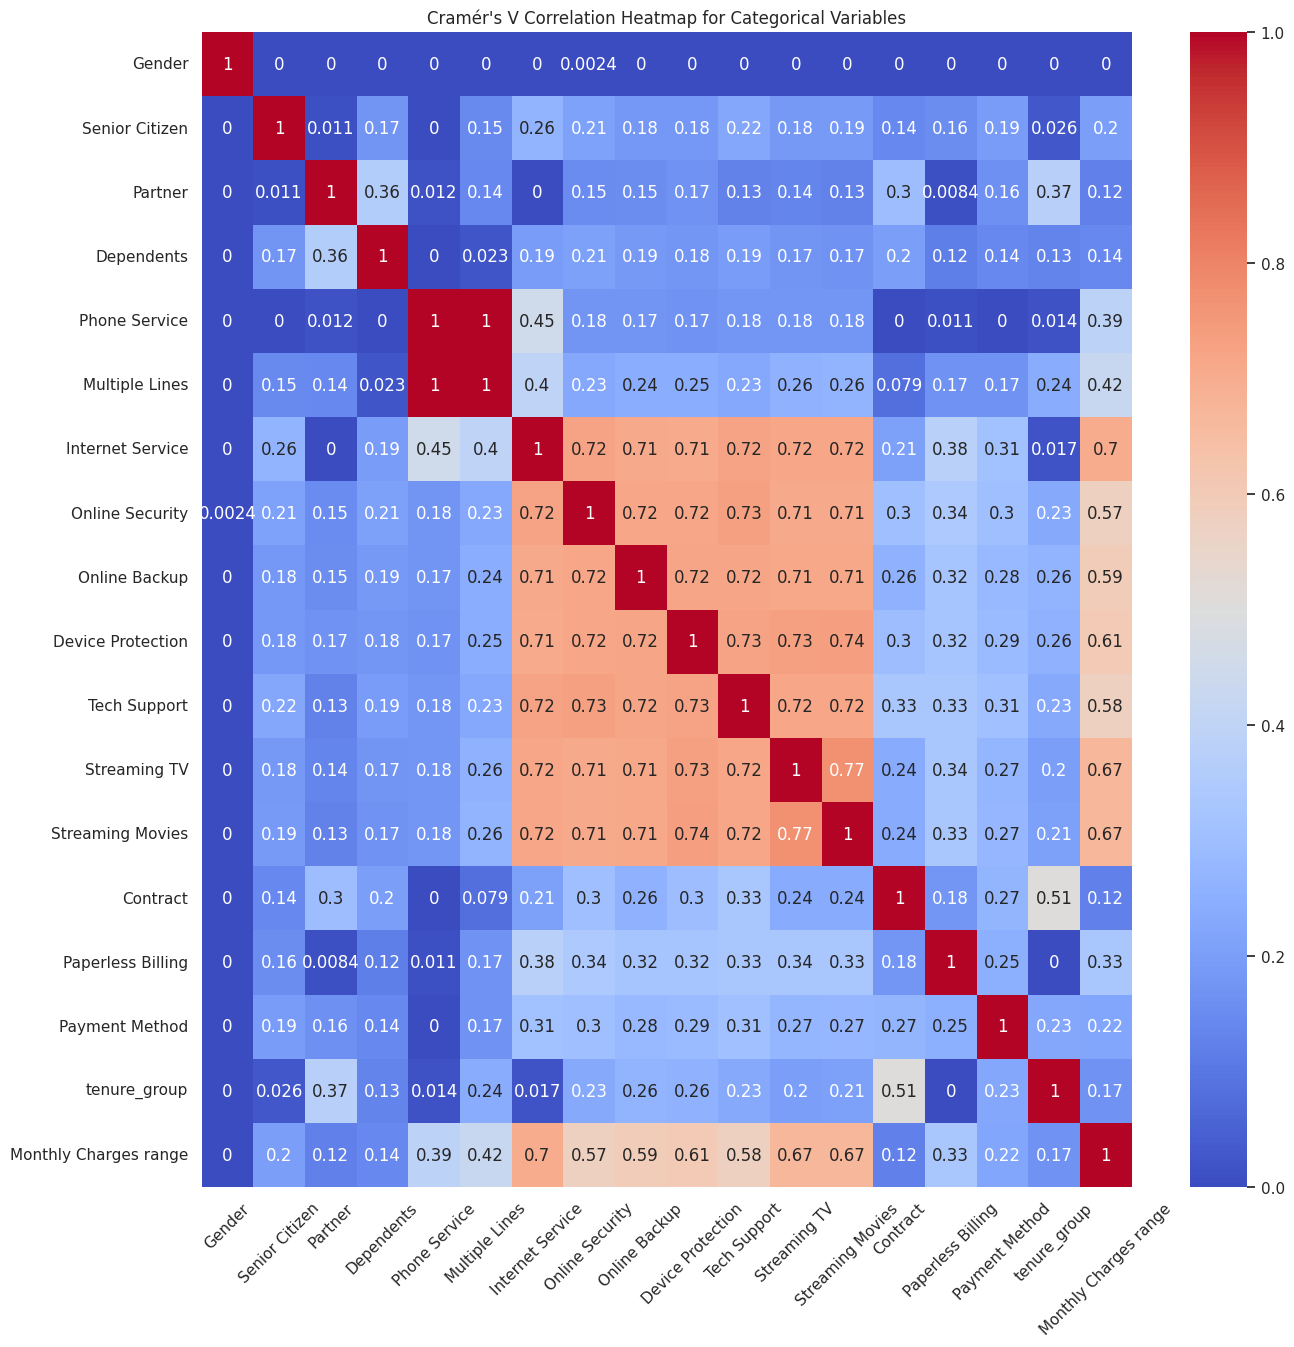

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm')
plt.title("Cramér's V Correlation Heatmap for Categorical Variables")
plt.xticks(rotation=45)
plt.show()


**Train/Test Splits**

In [ ]:
y = df['Churn Value']
X = df.drop(columns=['Churn Value'])

class_counts = y.value_counts()
scale_pos_weight = class_counts[0] / class_counts[1]
print(f" Calculated scale_pos_weight: {scale_pos_weight:.4f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


 Calculated scale_pos_weight: 2.7683


## Main Model (XGBoost)

##### Model hyper parameter tunning with 5-cv

In [ ]:
pipeline = Pipeline([
    ('woe', WOEEncoder()),
    ('model', XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    ))
])

params_extensive = {
    'model__n_estimators': randint(200, 1000),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__max_depth': randint(3, 10),
    'model__min_child_weight': randint(1, 10),
    'model__gamma': uniform(0, 0.5),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [1, 1.5, 2, 5],
    'model__scale_pos_weight': [scale_pos_weight, scale_pos_weight * 1.2]
}


search_extensive = RandomizedSearchCV(
    pipeline,
    param_distributions=params_extensive,
    n_iter=50,
    scoring='recall',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Starting Extensive Hyperparameter Tuning (this may take a while)...")
search_extensive.fit(X_train, y_train)


Starting Extensive Hyperparameter Tuning (this may take a while)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:47:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('woe', WOEEncoder()),
                                             ('model',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric='logloss',
                                                            feature_types=None,
                                                            feature_weights=None,
                                                            gamma=None,
                                                            grow_pol...
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ad74662ef90>,
                                        'model__reg_alpha': [0, 0.01, 0.1, 1],
                                        'model__reg_lambda': [1, 1.5, 2, 5],
                                        'model__scale_pos_weight': [np.float64(2.7683253076511503),
                                                                    np.float64(3.32199036918138)],
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ad747a24050>},
                   random_state=42, scoring='recall', verbose=1)

##### XGBoost model performance


Best Parameters Found:
{'model__colsample_bytree': np.float64(0.6057573954519023), 'model__gamma': np.float64(0.05803632025345812), 'model__learning_rate': np.float64(0.023800792606525824), 'model__max_depth': 3, 'model__min_child_weight': 4, 'model__n_estimators': 652, 'model__reg_alpha': 1, 'model__reg_lambda': 5, 'model__scale_pos_weight': np.float64(3.32199036918138), 'model__subsample': np.float64(0.9053457692015644)}

 XGBoost with Tuning Results:
Accuracy: 0.7459
Recall:   0.8422
Precision: 0.5130
F1 Score: 0.6377

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.71      0.80      1035
           1       0.51      0.84      0.64       374

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.75      0.76      1409



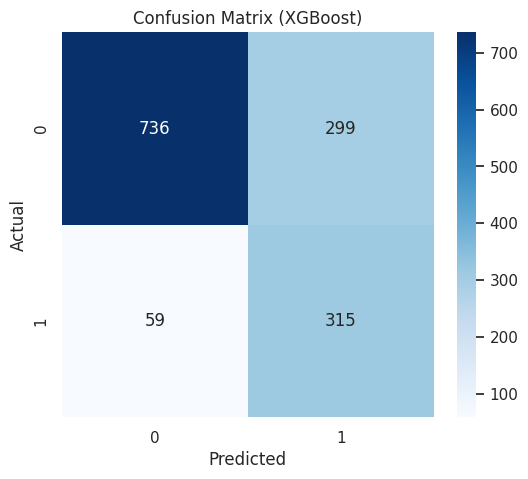

In [ ]:
best_model_ext = search_extensive.best_estimator_
y_pred_ext = best_model_ext.predict(X_test)

print("\nBest Parameters Found:")
print(search_extensive.best_params_)

print("\n XGBoost with Tuning Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ext):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred_ext):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ext):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_ext):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_ext))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_ext), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (XGBoost)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Feature Importance**

Features from Encoder: 21
Importances from Model: 21


/tmp/ipython-input-3972341034.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


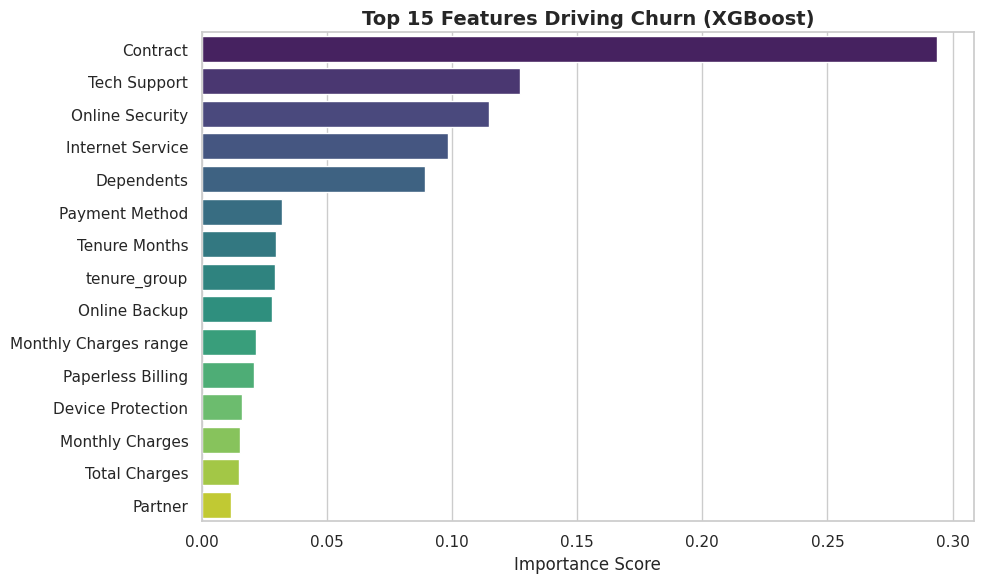

In [ ]:
xgb_model = best_model_ext.named_steps['model']
woe_encoder = best_model_ext.named_steps['woe']

try:
    feature_names = woe_encoder.get_feature_names_out()
except AttributeError:
    feature_names = woe_encoder.get_feature_names()

print(f"Features from Encoder: {len(feature_names)}")
print(f"Importances from Model: {len(xgb_model.feature_importances_)}")

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Features Driving Churn (XGBoost)', fontsize=14, weight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()


**ROC & Precision-Recall Curves**

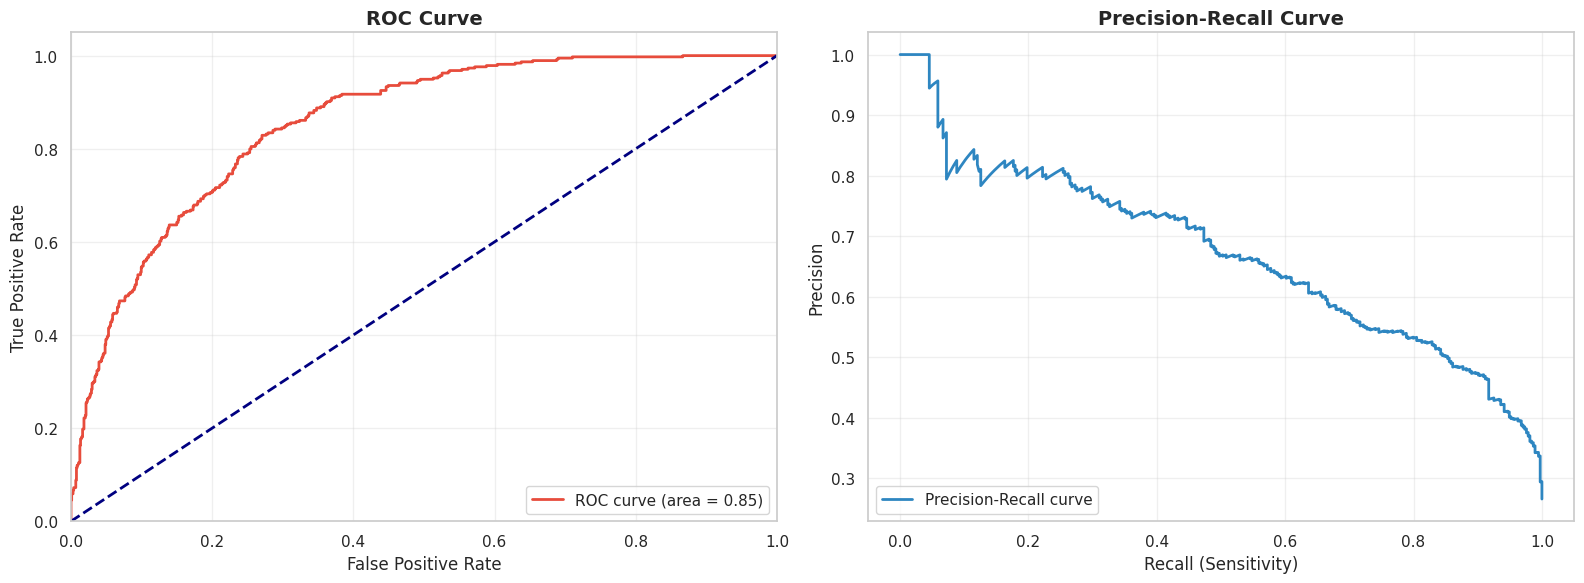

In [ ]:
y_prob = best_model_ext.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(fpr, tpr, color='#E74C3C', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=14, weight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].plot(recall, precision, color='#2E86C1', lw=2, label='Precision-Recall curve')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=14, weight='bold')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**5 Folds Cross Validation**

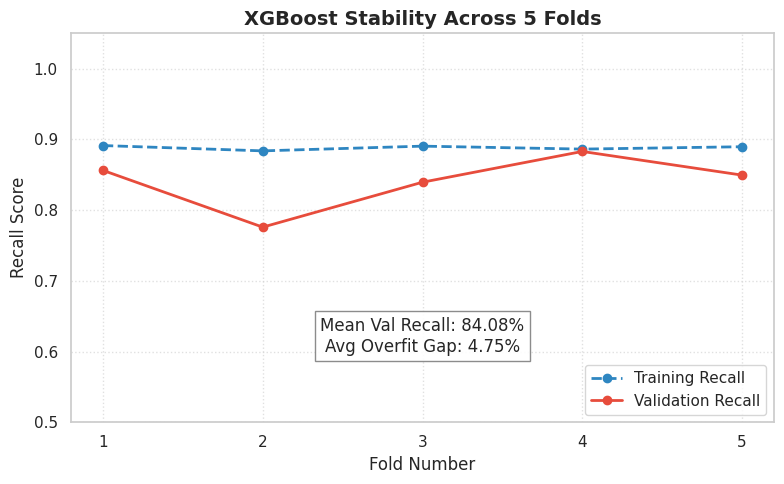

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    best_model_ext, X_train, y_train,
    cv=cv,
    scoring='recall',
    return_train_score=True,
    n_jobs=-1
)

train_scores = cv_results['train_score']
test_scores = cv_results['test_score']
folds = range(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(folds, train_scores, 'o--', color='#2E86C1', label='Training Recall', lw=2)
plt.plot(folds, test_scores, 'o-', color='#E74C3C', label='Validation Recall', lw=2)

plt.title(f'XGBoost Stability Across 5 Folds', fontsize=14, weight='bold')
plt.xlabel('Fold Number')
plt.ylabel('Recall Score')
plt.ylim(0.5, 1.05)
plt.xticks(folds)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

mean_val = np.mean(test_scores)
gap = np.mean(train_scores - test_scores)
plt.text(3, 0.6, f"Mean Val Recall: {mean_val:.2%}\nAvg Overfit Gap: {gap:.2%}",
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'), ha='center')

plt.tight_layout()
plt.show()

## Second Model (Random Forest)

##### Hyper parameter tunning for Random Forest with 5-cv

In [ ]:
rf_pipeline = Pipeline([
    ('woe', WOEEncoder()),
    ('model', RandomForestClassifier(random_state=42))
])


params_rf_extensive = {
    'model__n_estimators': randint(100, 1000),
    'model__max_depth': randint(5, 30),
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 10),
    'model__max_features': ['sqrt', 'log2', None],
    'model__class_weight': ['balanced', 'balanced_subsample'],
    'model__bootstrap': [True, False]
}


search_rf_extensive = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=params_rf_extensive,
    n_iter=50,
    scoring='recall',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Starting Extensive Hyperparameter Tuning for Random Forest...")
search_rf_extensive.fit(X_train, y_train)

Starting Extensive Hyperparameter Tuning for Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('woe', WOEEncoder()),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__bootstrap': [True, False],
                                        'model__class_weight': ['balanced',
                                                                'balanced_subsample'],
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ad74786fb00>,
                                        'm...
                                        'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ad7447f5dc0>,
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ad747711040>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ad74786ce00>},
                   random_state=42, scoring='recall', verbose=1)

##### Random Forest performance


Best RF Parameters Found:
{'model__bootstrap': False, 'model__class_weight': 'balanced_subsample', 'model__max_depth': 6, 'model__max_features': 'log2', 'model__min_samples_leaf': 6, 'model__min_samples_split': 11, 'model__n_estimators': 871}

Extensive Tuning Results (Honest Random Forest):
Accuracy: 0.7544
Recall:   0.7995
Precision: 0.5246
F1 Score: 0.6335

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



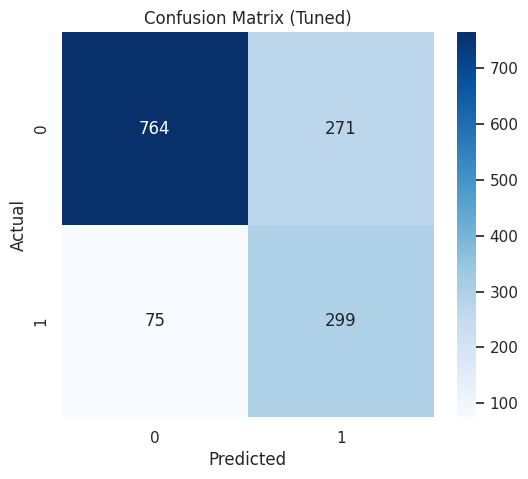

In [ ]:
best_rf_ext = search_rf_extensive.best_estimator_
y_pred_rf_ext = best_rf_ext.predict(X_test)

print("\nBest RF Parameters Found:")
print(search_rf_extensive.best_params_)

print("\nExtensive Tuning Results (Honest Random Forest):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_ext):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred_rf_ext):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_ext):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf_ext):.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_ext))


plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_ext), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Tuned)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Feature Importance**

/tmp/ipython-input-1637158672.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma') # Different palette for variety


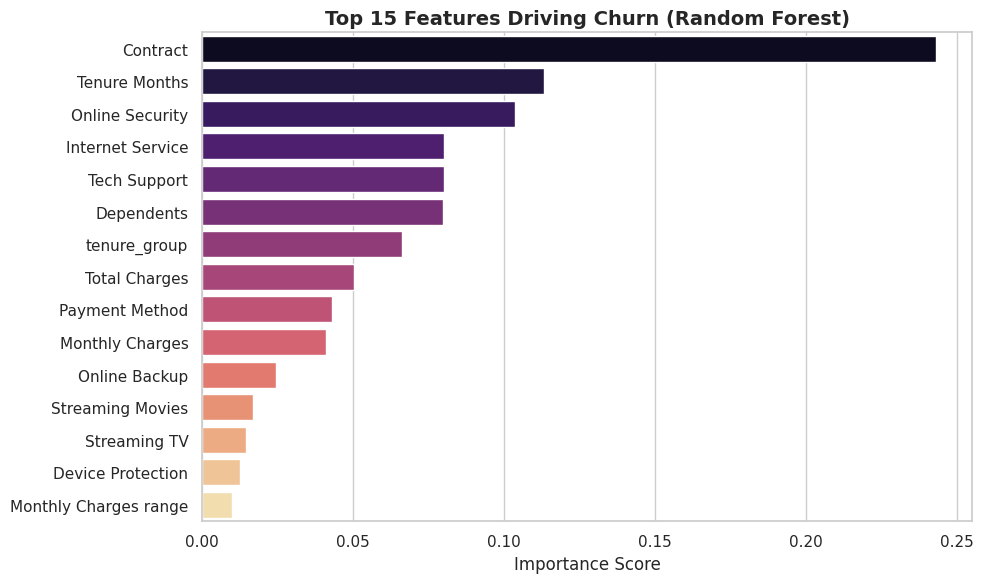

In [ ]:
rf_model = best_rf_ext.named_steps['model']
woe_encoder = best_rf_ext.named_steps['woe']

try:
    feature_names = woe_encoder.get_feature_names_out()
except AttributeError:
    feature_names = woe_encoder.get_feature_names()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)


plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma') # Different palette for variety
plt.title('Top 15 Features Driving Churn (Random Forest)', fontsize=14, weight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()


**ROC & Precision-Recall Curves**

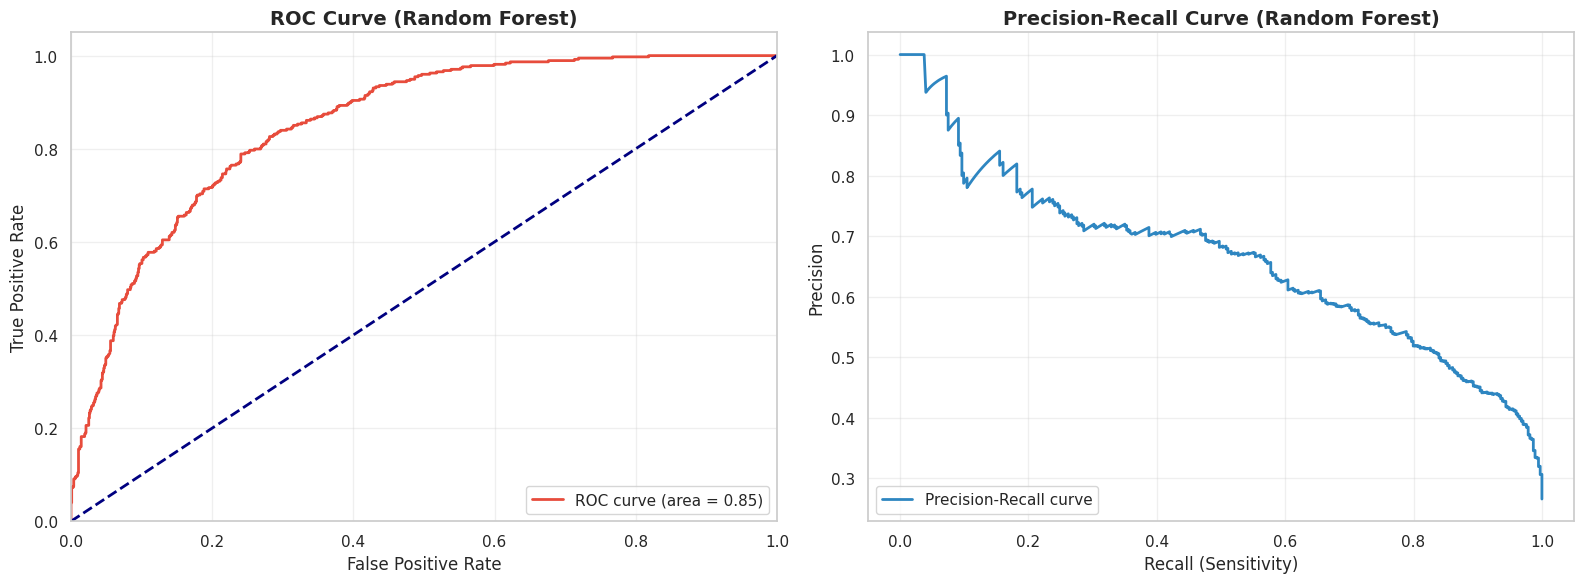

In [ ]:

y_prob = best_rf_ext.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


axes[0].plot(fpr, tpr, color='#E74C3C', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Random Forest)', fontsize=14, weight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].plot(recall, precision, color='#2E86C1', lw=2, label='Precision-Recall curve')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Random Forest)', fontsize=14, weight='bold')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**5-Fold CV on Best RF**

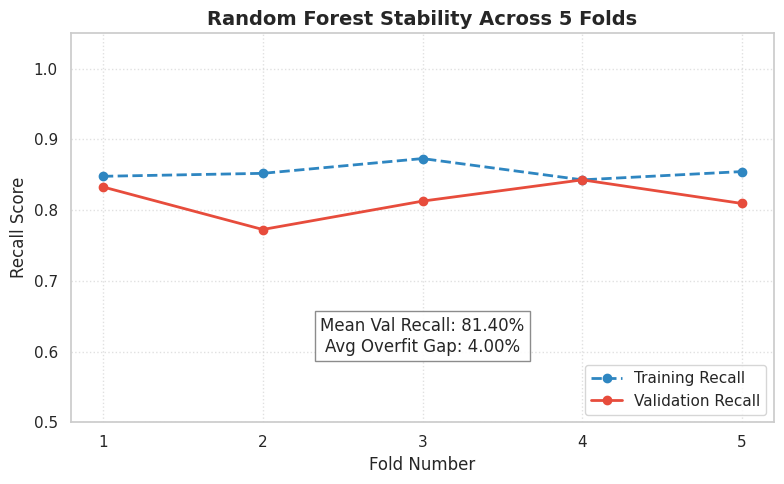

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    best_rf_ext, X_train, y_train,
    cv=cv,
    scoring='recall',
    return_train_score=True,
    n_jobs=-1
)

train_scores = cv_results['train_score']
test_scores = cv_results['test_score']
folds = range(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(folds, train_scores, 'o--', color='#2E86C1', label='Training Recall', lw=2)
plt.plot(folds, test_scores, 'o-', color='#E74C3C', label='Validation Recall', lw=2)

plt.title(f'Random Forest Stability Across 5 Folds', fontsize=14, weight='bold')
plt.xlabel('Fold Number')
plt.ylabel('Recall Score')
plt.ylim(0.5, 1.05)
plt.xticks(folds)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

mean_val = np.mean(test_scores)
gap = np.mean(train_scores - test_scores)
plt.text(3, 0.6, f"Mean Val Recall: {mean_val:.2%}\nAvg Overfit Gap: {gap:.2%}",
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'), ha='center')

plt.tight_layout()
plt.show()

#### Third Model, Ensemble model (soft voting with our best XGBoost and Random Forest models)

In [ ]:
rf_pipeline = Pipeline([
    ('woe', WOEEncoder()),
    ('rf', RandomForestClassifier(
        n_estimators=871,
        max_depth=6,
        min_samples_leaf=6,
        min_samples_split=11,
        class_weight='balanced_subsample',
        bootstrap=False,
        random_state=42
    ))
])

xgb_pipeline = best_model_ext

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_pipeline),
        ('xgb', xgb_pipeline)
    ],
    voting='soft'
)


print("Training Ensemble (RF + XGB)...")
ensemble.fit(X_train, y_train)



Training Ensemble (RF + XGB)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:12:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


VotingClassifier(estimators=[('rf',
                              Pipeline(steps=[('woe', WOEEncoder()),
                                              ('rf',
                                               RandomForestClassifier(bootstrap=False,
                                                                      class_weight='balanced_subsample',
                                                                      max_depth=6,
                                                                      min_samples_leaf=6,
                                                                      min_samples_split=11,
                                                                      n_estimators=871,
                                                                      random_state=42))])),
                             ('xgb',
                              Pipeline(steps=[('woe',
                                               WOEEncoder(cols=['Gender',
                                                                'Senior '
                                                                'Citizen',
                                                                'Partner',
                                                                'Dependents',
                                                                'Phone Servic...
                                                             importance_type=None,
                                                             interaction_constraints=None,
                                                             learning_rate=np.float64(0.023800792606525824),
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=3,
                                                             max_leaves=None,
                                                             min_child_weight=4,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=652,
                                                             n_jobs=None,
                                                             num_parallel_tree=None, ...))]))],
                 voting='soft')

##### Ensemble performance


--- Soft Voting Ensemble Results ---
Accuracy: 0.7509
Recall:   0.8209
Precision: 0.5195
F1 Score: 0.6363
ROC-AUC:   0.8549

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.73      0.81      1035
           1       0.52      0.82      0.64       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



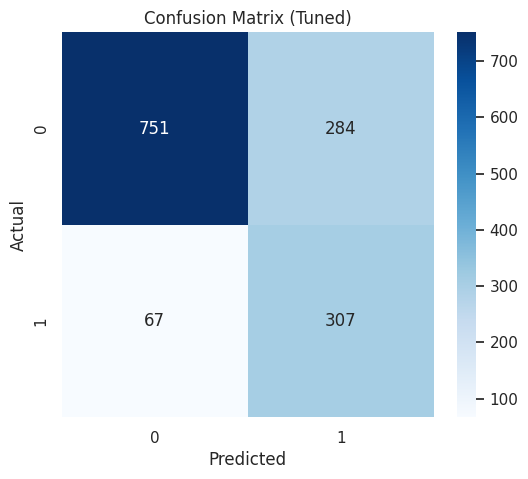

In [ ]:
y_pred_ens = ensemble.predict(X_test)
y_prob_ens = ensemble.predict_proba(X_test)[:, 1]

print("\n--- Soft Voting Ensemble Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ens):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred_ens):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ens):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_ens):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_ens):.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred_ens))


plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_ens), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Tuned)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Fourth model (CatBoost)

In [ ]:
df_c = pd.read_csv('Telco_customer_churn.csv')


drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
             'Lat Long', 'Latitude', 'Longitude', 'Churn Label',
             'Churn Score', 'CLTV', 'Churn Reason']
df_cat = df_c.drop(columns=[c for c in drop_cols if c in df_c.columns], errors='ignore')


cat_features_indices = np.where(df_cat.drop('Churn Value', axis=1).dtypes == object)[0]

X_c = df_cat.drop('Churn Value', axis=1)
y_c = df_cat['Churn Value']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y)


model_cb = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_features_indices,
    verbose=100,
    auto_class_weights='Balanced',
    eval_metric='Recall',
    random_seed=42
)

print("Training CatBoost...")
model_cb.fit(X_train_c, y_train_c, eval_set=(X_test_c, y_test_c), early_stopping_rounds=50)



Training CatBoost...
0:	learn: 0.7638796	test: 0.6925134	best: 0.6925134 (0)	total: 66.9ms	remaining: 1m 6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7860962567
bestIteration = 2

Shrink model to first 3 iterations.


##### CatBoost Performance


--- CatBoost Results ---
Accuracy: 0.7246
Recall:   0.7861
Precision: 0.4884
F1 Score: 0.6025

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.70      0.79      1035
           1       0.49      0.79      0.60       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.79      0.72      0.74      1409



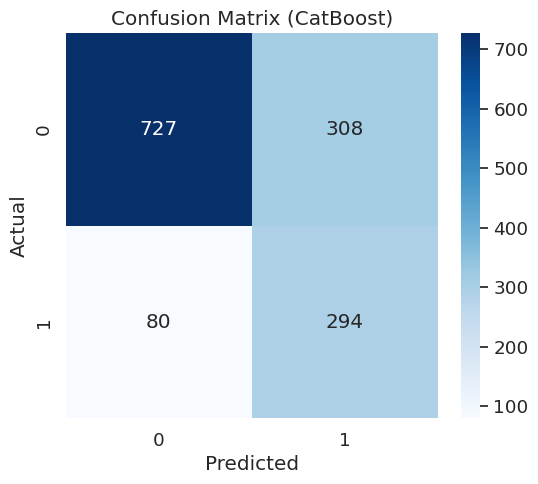

In [ ]:
y_pred_cb = model_cb.predict(X_test_c)

print("\n--- CatBoost Results ---")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_cb):.4f}")
print(f"Recall:   {recall_score(y_test_c, y_pred_cb):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_cb):.4f}")
print(f"F1 Score: {f1_score(y_test_c, y_pred_cb):.4f}")

print("\nClassification Report:\n", classification_report(y_test_c, y_pred_cb))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_c, y_pred_cb), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (CatBoost)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### Fifth Model, Hard Voting Ensemble with our 3 models

In [ ]:
rf_pipeline = Pipeline([
    ('woe', WOEEncoder()),
    ('rf', RandomForestClassifier(
        n_estimators=871,
        max_depth=6,
        min_samples_leaf=6,
        min_samples_split=11,
        class_weight='balanced_subsample',
        bootstrap=False,
        random_state=42
    ))
])


xgb_pipeline = Pipeline([
    ('woe', WOEEncoder()),
    ('xgb', XGBClassifier(
        n_estimators=652,
        learning_rate=0.024,
        max_depth=3,
        min_child_weight=4,
        gamma=0.058,
        colsample_bytree=0.6,
        scale_pos_weight=3.32,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    ))
])

cat_features_indices = np.where((X_train.dtypes == 'object') | (X_train.dtypes == 'category'))[0]

cb_model = CatBoostClassifier(
    iterations=353,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_features_indices,
    auto_class_weights='Balanced',
    verbose=0,
    random_seed=42
)


def clean_for_catboost(X):
    X_copy = X.copy()

    cat_cols = X_copy.select_dtypes(include=['object', 'category']).columns

    for col in cat_cols:
        X_copy[col] = X_copy[col].astype('object')
        X_copy[col] = X_copy[col].fillna('Missing')
        X_copy[col] = X_copy[col].astype(str)

    return X_copy


cb_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(clean_for_catboost, validate=False)),
    ('cb', cb_model)
])

voting_hard = VotingClassifier(
    estimators=[
        ('rf', rf_pipeline),
        ('xgb', xgb_pipeline),
        ('cb', cb_pipeline)
    ],
    voting='hard'
)

print("Training 3-Model Hard Voting Ensemble (Safe Mode)...")
voting_hard.fit(X_train, y_train)

Training 3-Model Hard Voting Ensemble (Safe Mode)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:44:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


VotingClassifier(estimators=[('rf',
                              Pipeline(steps=[('woe', WOEEncoder()),
                                              ('rf',
                                               RandomForestClassifier(bootstrap=False,
                                                                      class_weight='balanced_subsample',
                                                                      max_depth=6,
                                                                      min_samples_leaf=6,
                                                                      min_samples_split=11,
                                                                      n_estimators=871,
                                                                      random_state=42))])),
                             ('xgb',
                              Pipeline(steps=[('woe', WOEEncoder()),
                                              ('xgb',
                                               XGBClassifier(base_score=None,
                                                             booster=None,
                                                             callbacks=None,...
                                                             max_delta_step=None,
                                                             max_depth=3,
                                                             max_leaves=None,
                                                             min_child_weight=4,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=652,
                                                             n_jobs=None,
                                                             num_parallel_tree=None, ...))])),
                             ('cb',
                              Pipeline(steps=[('cleaner',
                                               FunctionTransformer(func=<function clean_for_catboost at 0x7ad7441587c0>)),
                                              ('cb',
                                               <catboost.core.CatBoostClassifier object at 0x7ad744209070>)]))])

##### Hard Voting Ensemble performance


--- Hard Voting Ensemble Results ---
Accuracy: 0.7573
Recall:   0.8128
Precision: 0.5278
F1 Score: 0.6400

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.74      0.82      1035
           1       0.53      0.81      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



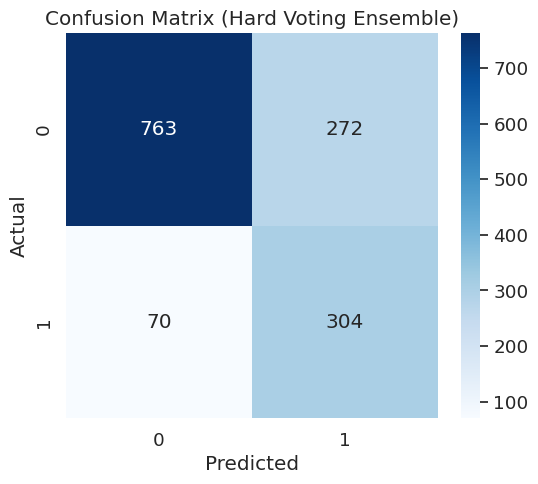

In [ ]:
y_pred_hard = voting_hard.predict(X_test)

print("\n--- Hard Voting Ensemble Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_hard):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred_hard):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_hard):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_hard):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_hard))


plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_hard), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Hard Voting Ensemble)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Models performances graph

Calculating metrics for all 5 models...


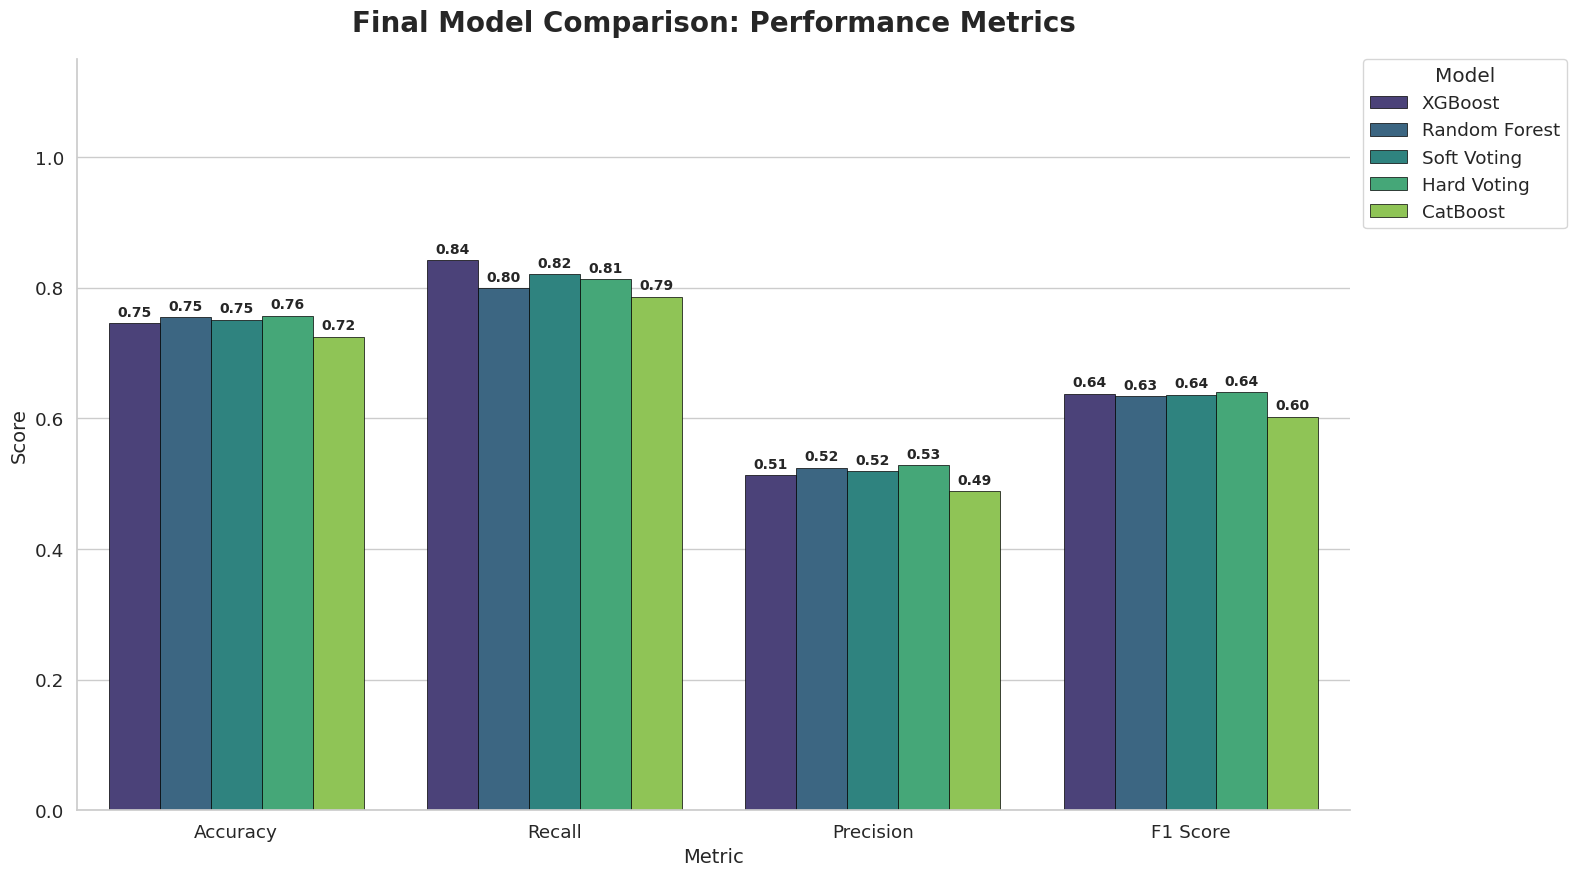


--- Final Performance Table ---


,Accuracy,Recall,Precision,F1 Score
Model,,,,
XGBoost,0.745919,0.842246,0.513029,0.637652
Random Forest,0.754436,0.799465,0.524561,0.633475
Soft Voting,0.750887,0.820856,0.519459,0.636269
Hard Voting,0.757275,0.812834,0.527778,0.640000
CatBoost,0.724627,0.786096,0.488372,0.602459


In [ ]:
models_config = [
    ('XGBoost', best_model_ext, X_test, y_test),
    ('Random Forest', best_rf_ext, X_test, y_test),
    ('Soft Voting', ensemble, X_test, y_test),
    ('Hard Voting', voting_hard, X_test, y_test),
    ('CatBoost', model_cb, X_test_c, y_test_c)
]

metrics_data = []
print("Calculating metrics for all 5 models...")

for name, model, X_val, y_val in models_config:
    y_pred = model.predict(X_val)

    metrics_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'F1 Score': f1_score(y_val, y_pred)
    })

df_metrics = pd.DataFrame(metrics_data)
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 9))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

ax = sns.barplot(
    data=df_melted,
    x='Metric',
    y='Score',
    hue='Model',
    palette='viridis',
    edgecolor='black',
    linewidth=0.5
)


for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10, fontweight='bold')

plt.title('Final Model Comparison: Performance Metrics', fontsize=20, weight='bold', pad=20)
plt.ylabel('Score', fontsize=14)
plt.xlabel('Metric', fontsize=14)
plt.ylim(0, 1.15)
plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
sns.despine()

plt.tight_layout()
plt.show()

print("\n--- Final Performance Table ---")
display(df_metrics.set_index('Model').style.highlight_max(axis=0, color='lightgreen'))